In [2]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"] = "xx"

In [4]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 15 file(s) under /src/
src/cl_strategies/ewc.py -> /content/src/cl_strategies/ewc.py
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/meta_learning/mamal.py -> /content/src/meta_learning/mamal.py
src/meta_learning/reptil.py -> /content/src/meta_learning/reptil.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/p

In [5]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh    # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [6]:
# imports
%run /content/src/imports.py

Using device: cuda


In [7]:
# BASE
cfg.OUTPUT_ROOT = "./UCF101/processed_data_base"
preprocess_dataset(splits=["train", "test"], target_classes=cfg.SELECTED_CLASSES)


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_base
Classes: 10 | Limit: Full

Processing split: train



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_base


In [8]:

# TASK 1
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task1"
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_1)

# TASK 2
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task2"
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_2)

# TASK 3
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task3"
#preprocess_dataset(splits=["train", "val", "test"])

# TASK 4
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task4"
#preprocess_dataset(splits=["train", "val", "test"])


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task1
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task2
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task2


## **Fisher matrix on traning data**

In [9]:
EWC_LAMBDA = 5000.0 # hyperparameter for EWC regularization strength

# indexes
ALL_CLASSES_LIST      = cfg.SELECTED_CLASSES + cfg.TASK_1
class_to_idx          = {cls: i for i, cls in enumerate(ALL_CLASSES_LIST)}
original_class_to_idx = {cls: i for i, cls in enumerate(cfg.SELECTED_CLASSES)}
total_classes         = len(ALL_CLASSES_LIST)

# datasets
base_test    = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx)
task1_train  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val    = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

# loaders
base_test_loader     = DataLoader(base_test,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_train_loader   = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader     = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader    = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
combined_test_loader = DataLoader(ConcatDataset([base_test, task1_test]),
                                  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
# fisher loader for base task
base_fisher_loader   = DataLoader(
    UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=original_class_to_idx),
    batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2
)

In [10]:
# load base model 10 classes not yet expanded
model_ewc = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
model_ewc.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s] 


<All keys matched successfully>

In [11]:
fisher_dict, optpar_dict = {}, {}
fisher_dict, optpar_dict = compute_fisher(
    model_ewc, base_fisher_loader, device,
    task_id=0, fisher_dict=fisher_dict, optpar_dict=optpar_dict
)

[Fisher] task_id=0 | samples=994 | mean=0.0276


In [12]:
model_ewc = expand_classifier(model_ewc, new_num_classes=total_classes).to(device)
print(f"FC expanded {len(cfg.SELECTED_CLASSES)} -> {total_classes} classes")
fisher_dict, optpar_dict = pad_fisher_after_expand(fisher_dict, optpar_dict, model_ewc)

FC expanded 10 -> 13 classes
  [pad] fc.weight: torch.Size([10, 256]) → torch.Size([13, 256])
  [pad] fc.bias: torch.Size([10]) → torch.Size([13])


In [16]:
optimizer_t1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ewc.parameters()),
    lr=1e-5, weight_decay=1e-4
)
train_ewc_simple(
    model_ewc,
    task1_train_loader,
    task1_val_loader,
    optimizer_t1,
    device,                  
    fisher_dict=fisher_dict,
    optpar_dict=optpar_dict,
    ewc_lambda=EWC_LAMBDA, 
    epochs=5,
    task_label="Task1"
)

[Task1] Epoch 01/5 | Loss 2.9187 (CE 2.7841 + EWC 0.1347) | Val Acc 0.2400
[Task1] Epoch 02/5 | Loss 2.0466 (CE 1.7996 + EWC 0.2471) | Val Acc 0.7400
[Task1] Epoch 03/5 | Loss 1.4177 (CE 1.0661 + EWC 0.3516) | Val Acc 0.9000
[Task1] Epoch 04/5 | Loss 1.0561 (CE 0.6842 + EWC 0.3719) | Val Acc 0.8800
[Task1] Epoch 05/5 | Loss 0.8521 (CE 0.5051 + EWC 0.3470) | Val Acc 0.9000


In [17]:
ewc_report(model_ewc, fisher_dict, optpar_dict)


  Task 0 | Mean Fisher: 0.0254 | Mean Drift: 0.000019 | Total Penalty: 0.0001
    1. resnet.7.2.conv2.weight                         17.2%
    2. resnet.7.2.conv3.weight                         16.4%
    3. lstm.weight_ih_l0                               16.4%
    4. resnet.7.0.downsample.0.weight                  10.6%
    5. resnet.7.2.conv1.weight                          7.4%


Running Inference on Test Set...


Test Accuracy: 0.9375


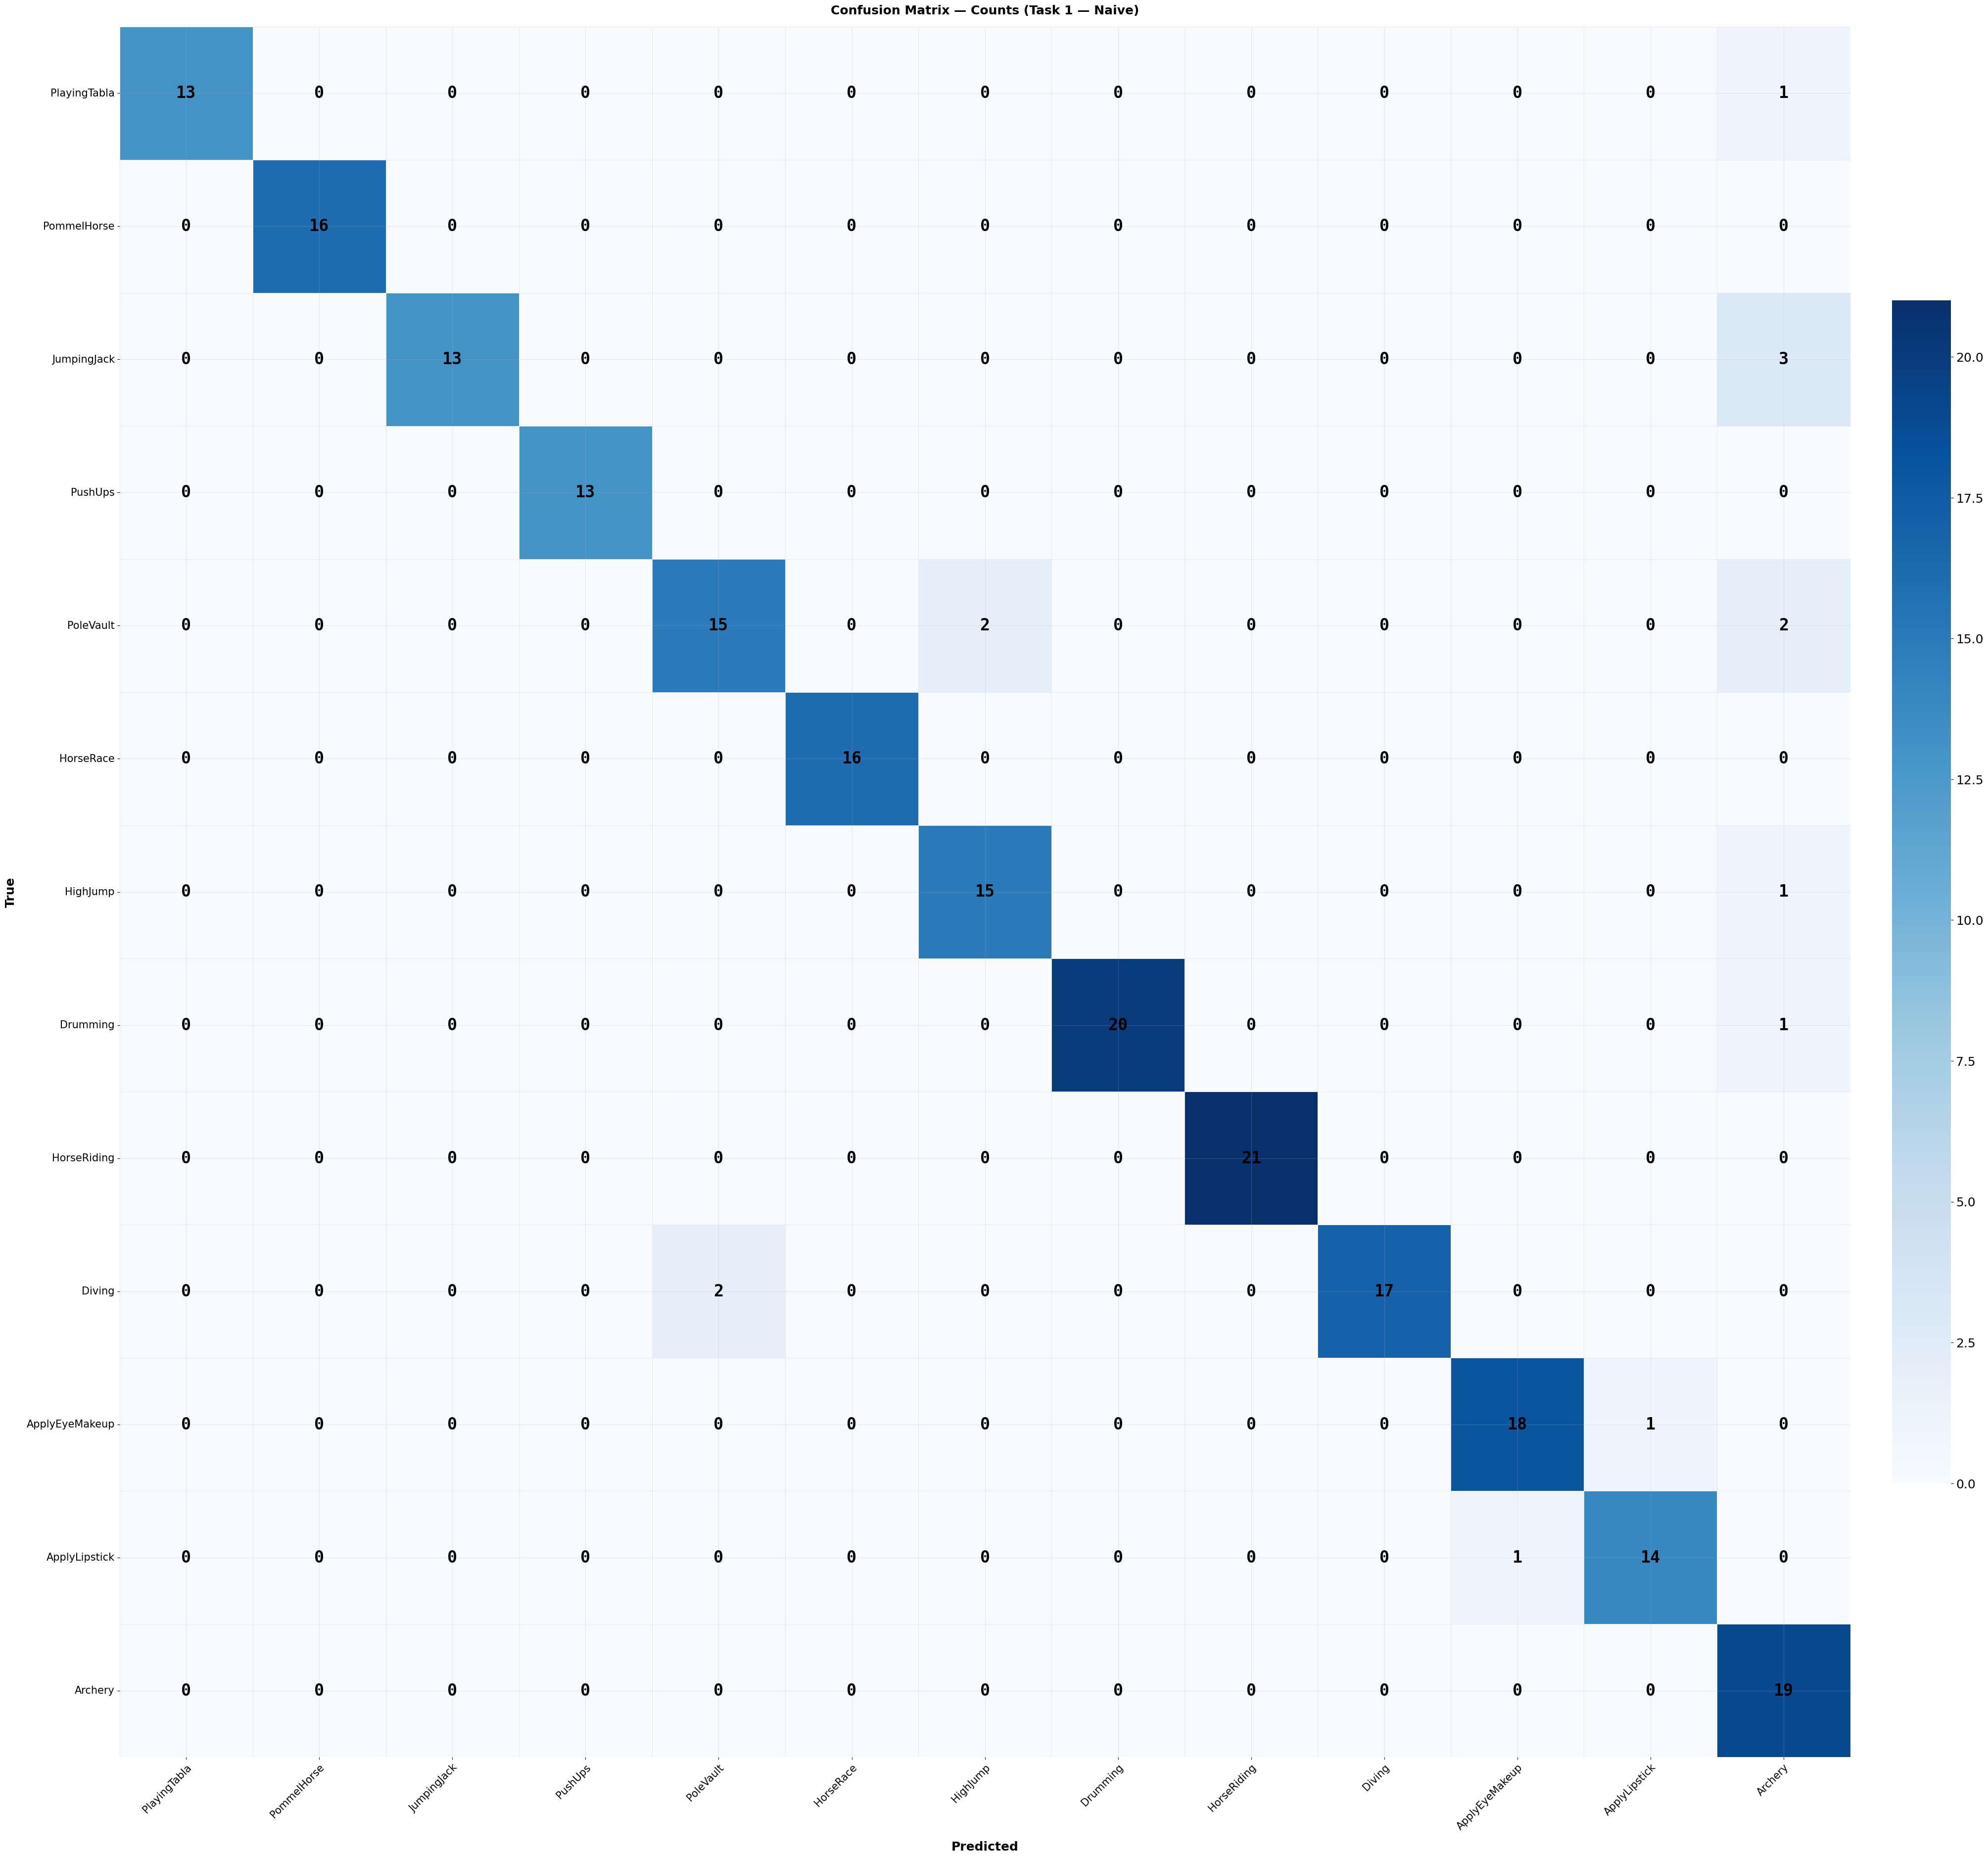

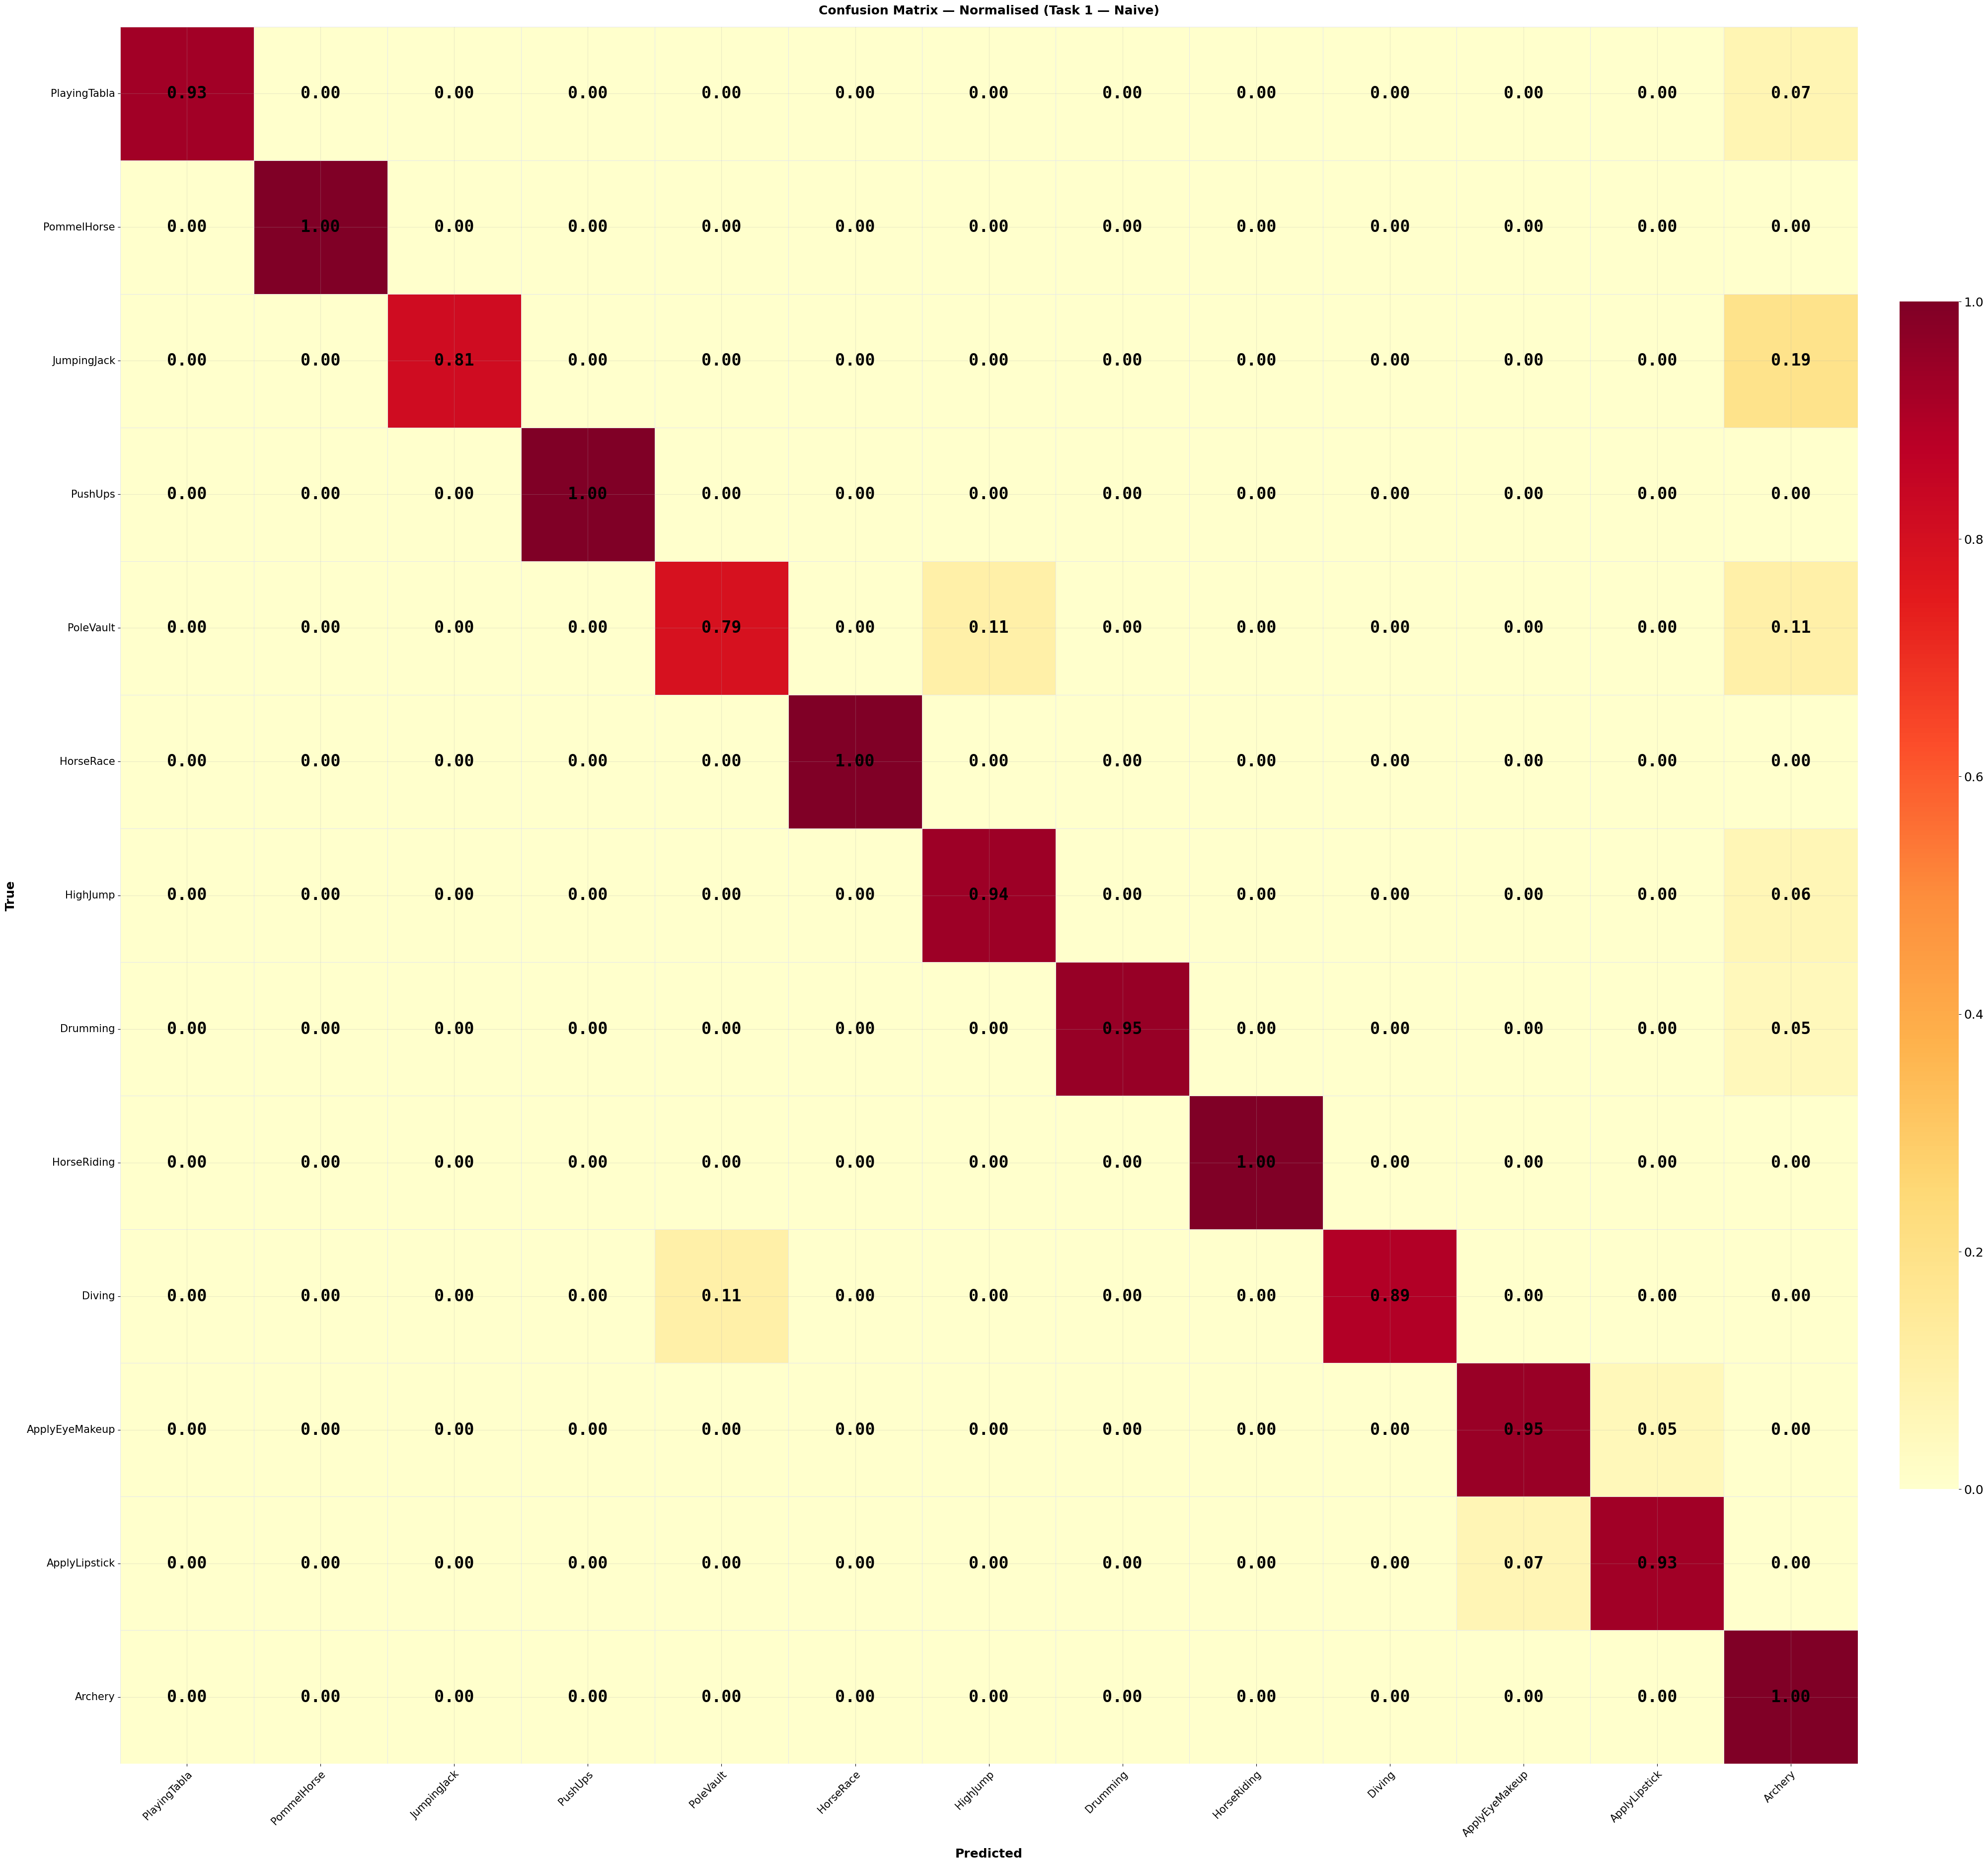

In [18]:
_, all_preds, all_labels = test_model(model_ewc, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = "Task 1 — Naive",
)

## **Task 2**

In [19]:
ALL_CLASSES_T2   = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx_t2  = {cls: i for i, cls in enumerate(ALL_CLASSES_T2)}
total_classes_t2 = len(ALL_CLASSES_T2)

base_test_t2  = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx_t2)
task1_test_t2 = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx_t2)

task2_train   = UCF101Clips(os.path.join(cfg.OUTPUT_ROOT, "train"), class_to_idx=class_to_idx_t2)
task2_val     = UCF101Clips(os.path.join(cfg.OUTPUT_ROOT, "val"),   class_to_idx=class_to_idx_t2)
task2_test    = UCF101Clips(os.path.join(cfg.OUTPUT_ROOT, "test"),  class_to_idx=class_to_idx_t2)

base_test_t2_loader   = DataLoader(base_test_t2,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_t2_loader  = DataLoader(task1_test_t2, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_train_loader    = DataLoader(task2_train,   batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader      = DataLoader(task2_val,     batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader     = DataLoader(task2_test,    batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
combined_t2_loader    = DataLoader(
    ConcatDataset([base_test_t2, task1_test_t2, task2_test]),
    batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2
)
task1_fisher_loader   = DataLoader(
    UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx_t2),
    batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2
)

In [20]:
compute_fisher(model_ewc, task1_fisher_loader, device, task_id=1, fisher_dict=fisher_dict, optpar_dict=optpar_dict)

[Fisher] task_id=1 | samples=301 | mean=0.0272


({0: {'resnet.7.0.conv1.weight': tensor([[[[1.6690e-04]],
   
            [[1.0665e-03]],
   
            [[1.5682e-04]],
   
            ...,
   
            [[3.0148e-04]],
   
            [[1.8176e-03]],
   
            [[1.3699e-04]]],
   
   
           [[[1.6465e-04]],
   
            [[7.1681e-04]],
   
            [[4.7387e-04]],
   
            ...,
   
            [[9.2252e-05]],
   
            [[1.1056e-03]],
   
            [[1.6381e-04]]],
   
   
           [[[4.2302e-04]],
   
            [[4.9940e-03]],
   
            [[1.8014e-03]],
   
            ...,
   
            [[3.1821e-04]],
   
            [[1.0063e-03]],
   
            [[1.2653e-04]]],
   
   
           ...,
   
   
           [[[1.2530e-04]],
   
            [[2.6890e-04]],
   
            [[3.0086e-04]],
   
            ...,
   
            [[5.6506e-05]],
   
            [[8.3621e-04]],
   
            [[2.0554e-04]]],
   
   
           [[[3.1641e-04]],
   
            [[2.9786e-04]],
   
          

In [21]:
model_ewc = expand_classifier(model_ewc, new_num_classes=total_classes_t2).to(device)
print(f" FC expanded 13 -> {total_classes_t2} classes")
pad_fisher_after_expand(fisher_dict, optpar_dict, model_ewc)

 FC expanded 13 -> 16 classes
  [pad] fc.weight: torch.Size([13, 256]) → torch.Size([16, 256])
  [pad] fc.bias: torch.Size([13]) → torch.Size([16])
  [pad] fc.weight: torch.Size([13, 256]) → torch.Size([16, 256])
  [pad] fc.bias: torch.Size([13]) → torch.Size([16])


({0: {'resnet.7.0.conv1.weight': tensor([[[[1.6690e-04]],
   
            [[1.0665e-03]],
   
            [[1.5682e-04]],
   
            ...,
   
            [[3.0148e-04]],
   
            [[1.8176e-03]],
   
            [[1.3699e-04]]],
   
   
           [[[1.6465e-04]],
   
            [[7.1681e-04]],
   
            [[4.7387e-04]],
   
            ...,
   
            [[9.2252e-05]],
   
            [[1.1056e-03]],
   
            [[1.6381e-04]]],
   
   
           [[[4.2302e-04]],
   
            [[4.9940e-03]],
   
            [[1.8014e-03]],
   
            ...,
   
            [[3.1821e-04]],
   
            [[1.0063e-03]],
   
            [[1.2653e-04]]],
   
   
           ...,
   
   
           [[[1.2530e-04]],
   
            [[2.6890e-04]],
   
            [[3.0086e-04]],
   
            ...,
   
            [[5.6506e-05]],
   
            [[8.3621e-04]],
   
            [[2.0554e-04]]],
   
   
           [[[3.1641e-04]],
   
            [[2.9786e-04]],
   
          

In [22]:
optimizer_t2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ewc.parameters()),
    lr=1e-5, weight_decay=1e-4
)
train_ewc_simple(
    model_ewc,
    task2_train_loader,
    task2_val_loader,
    optimizer_t2,
    device,                  
    fisher_dict=fisher_dict,
    optpar_dict=optpar_dict,
    ewc_lambda=EWC_LAMBDA, 
    epochs=5,
    task_label="Task2"
)

[Task2] Epoch 01/5 | Loss 3.2785 (CE 2.7994 + EWC 0.4792) | Val Acc 0.0377
[Task2] Epoch 02/5 | Loss 2.3844 (CE 1.7843 + EWC 0.6001) | Val Acc 0.7736
[Task2] Epoch 03/5 | Loss 1.9480 (CE 1.2799 + EWC 0.6681) | Val Acc 0.8868
[Task2] Epoch 04/5 | Loss 1.7106 (CE 1.0328 + EWC 0.6778) | Val Acc 0.9434
[Task2] Epoch 05/5 | Loss 1.5479 (CE 0.8819 + EWC 0.6660) | Val Acc 0.9434


Running Inference on Test Set...


Test Accuracy: 0.7849


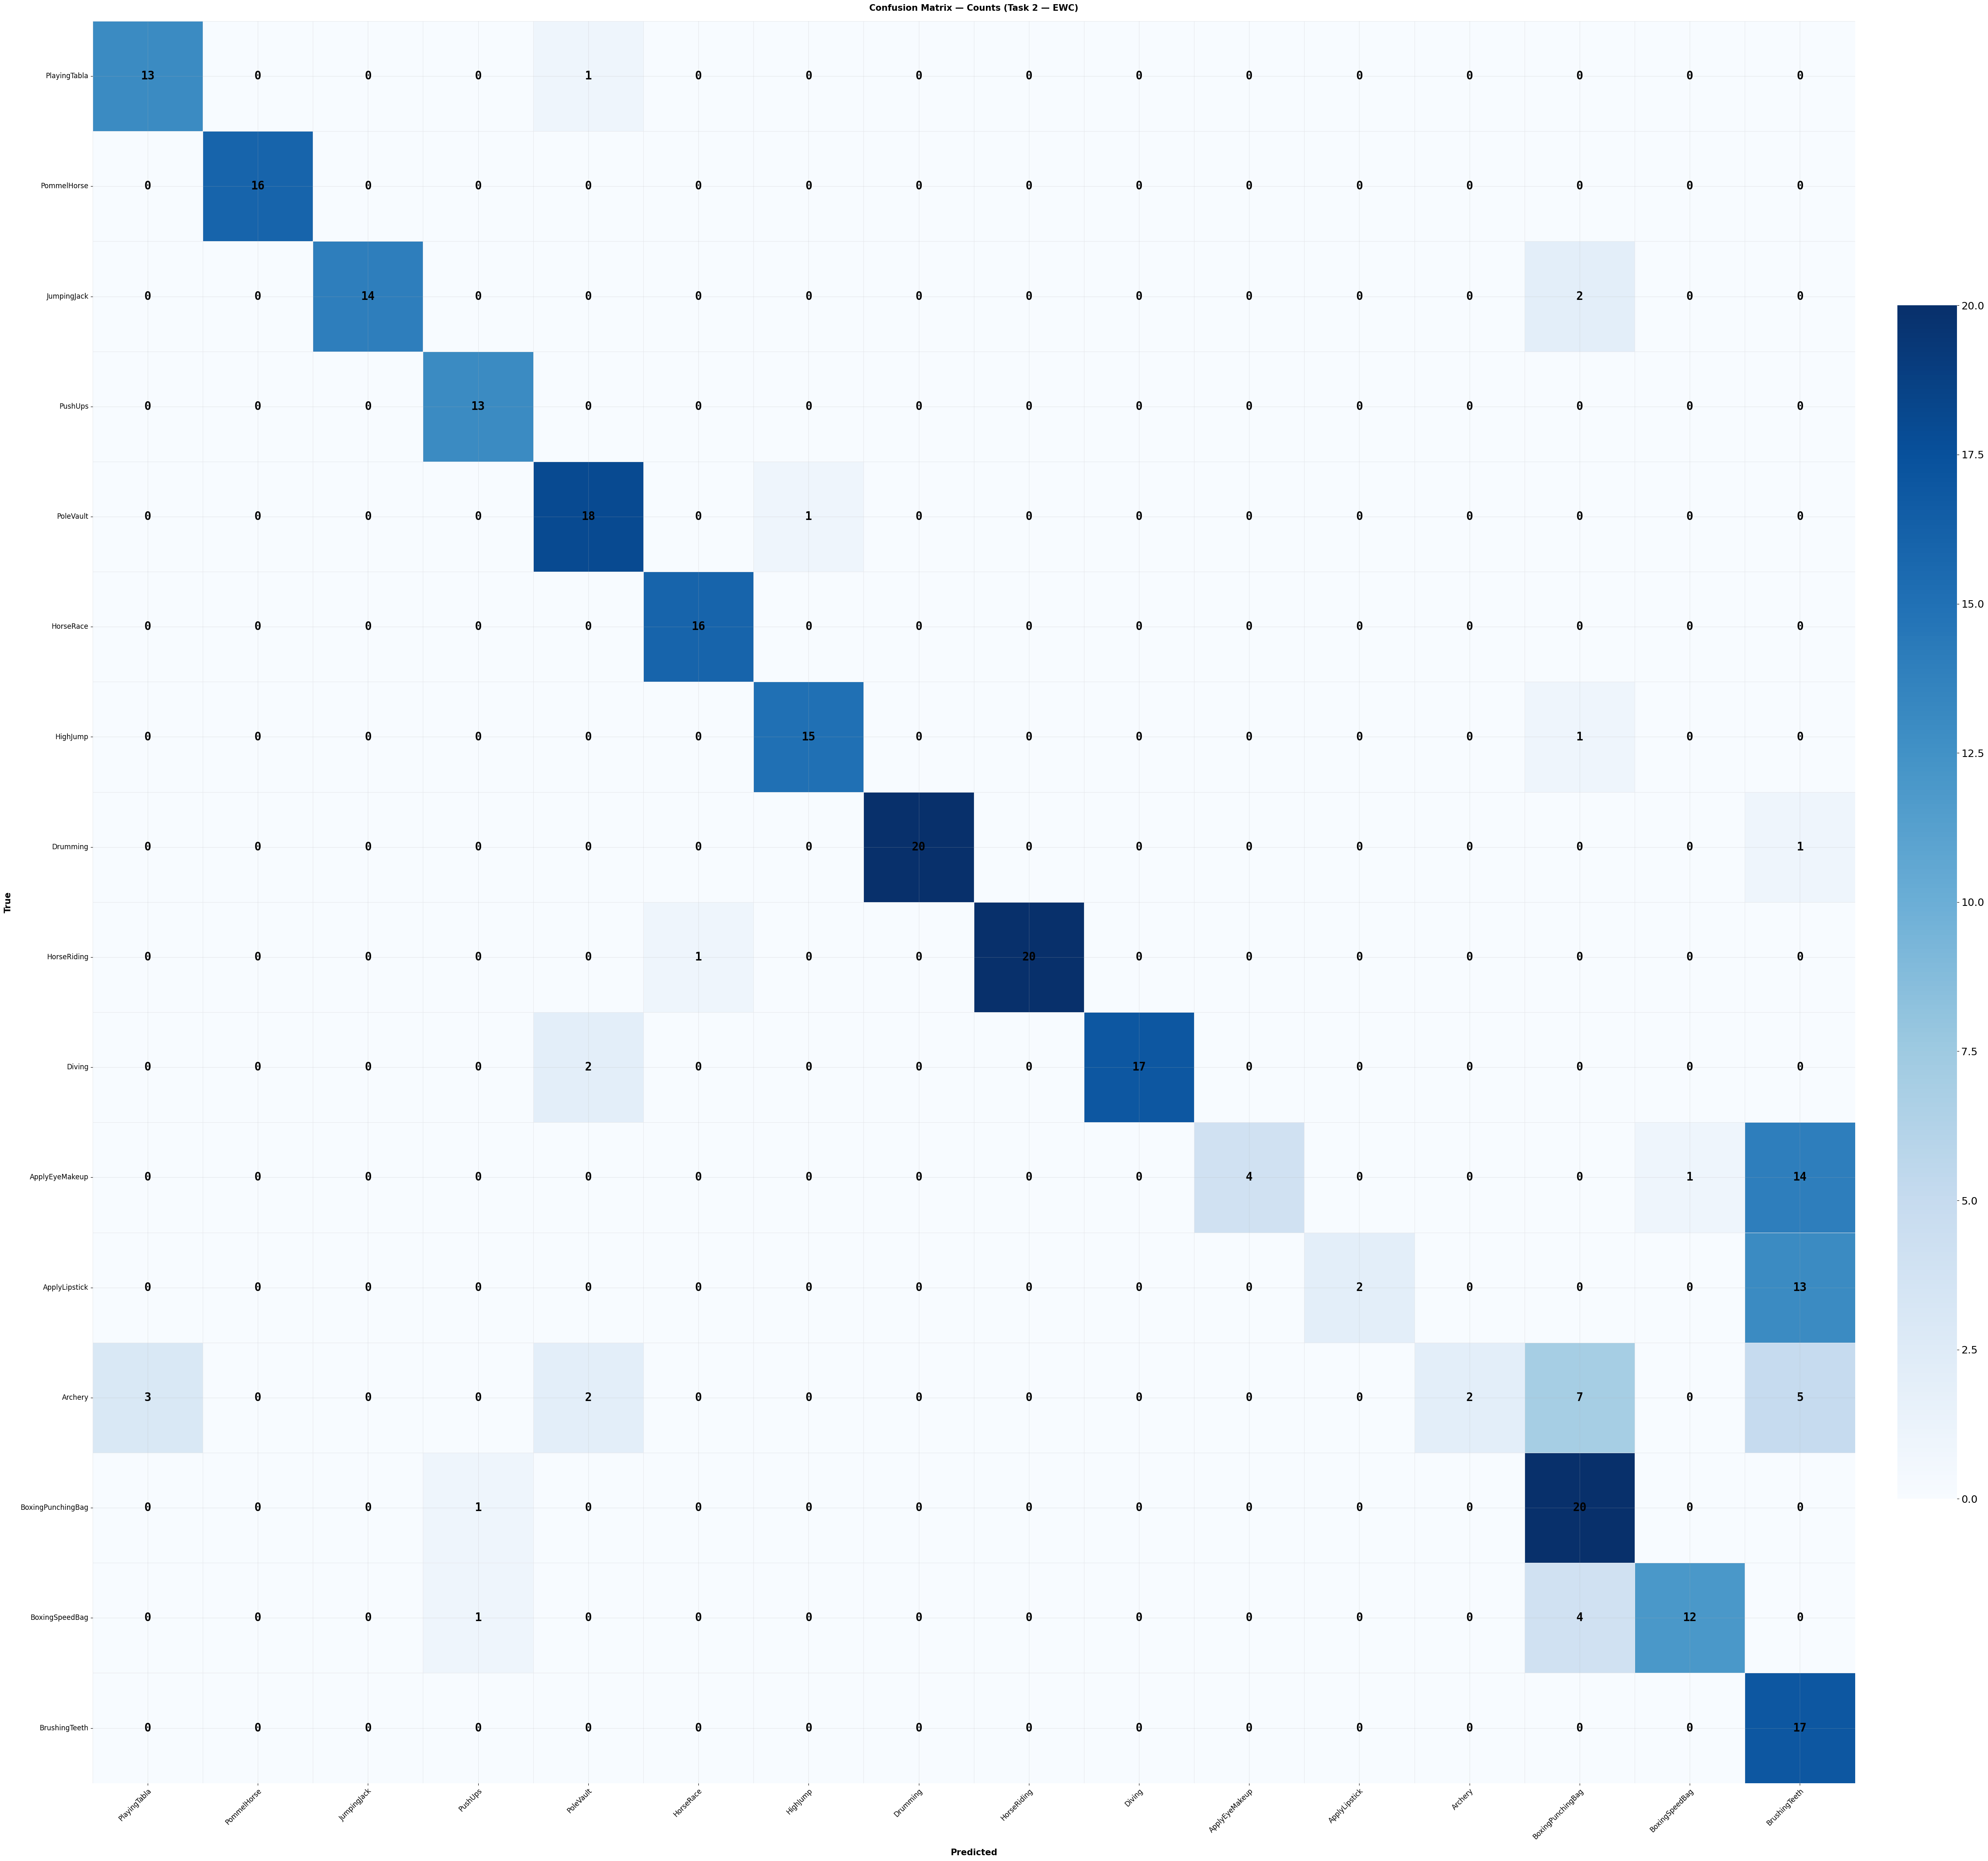

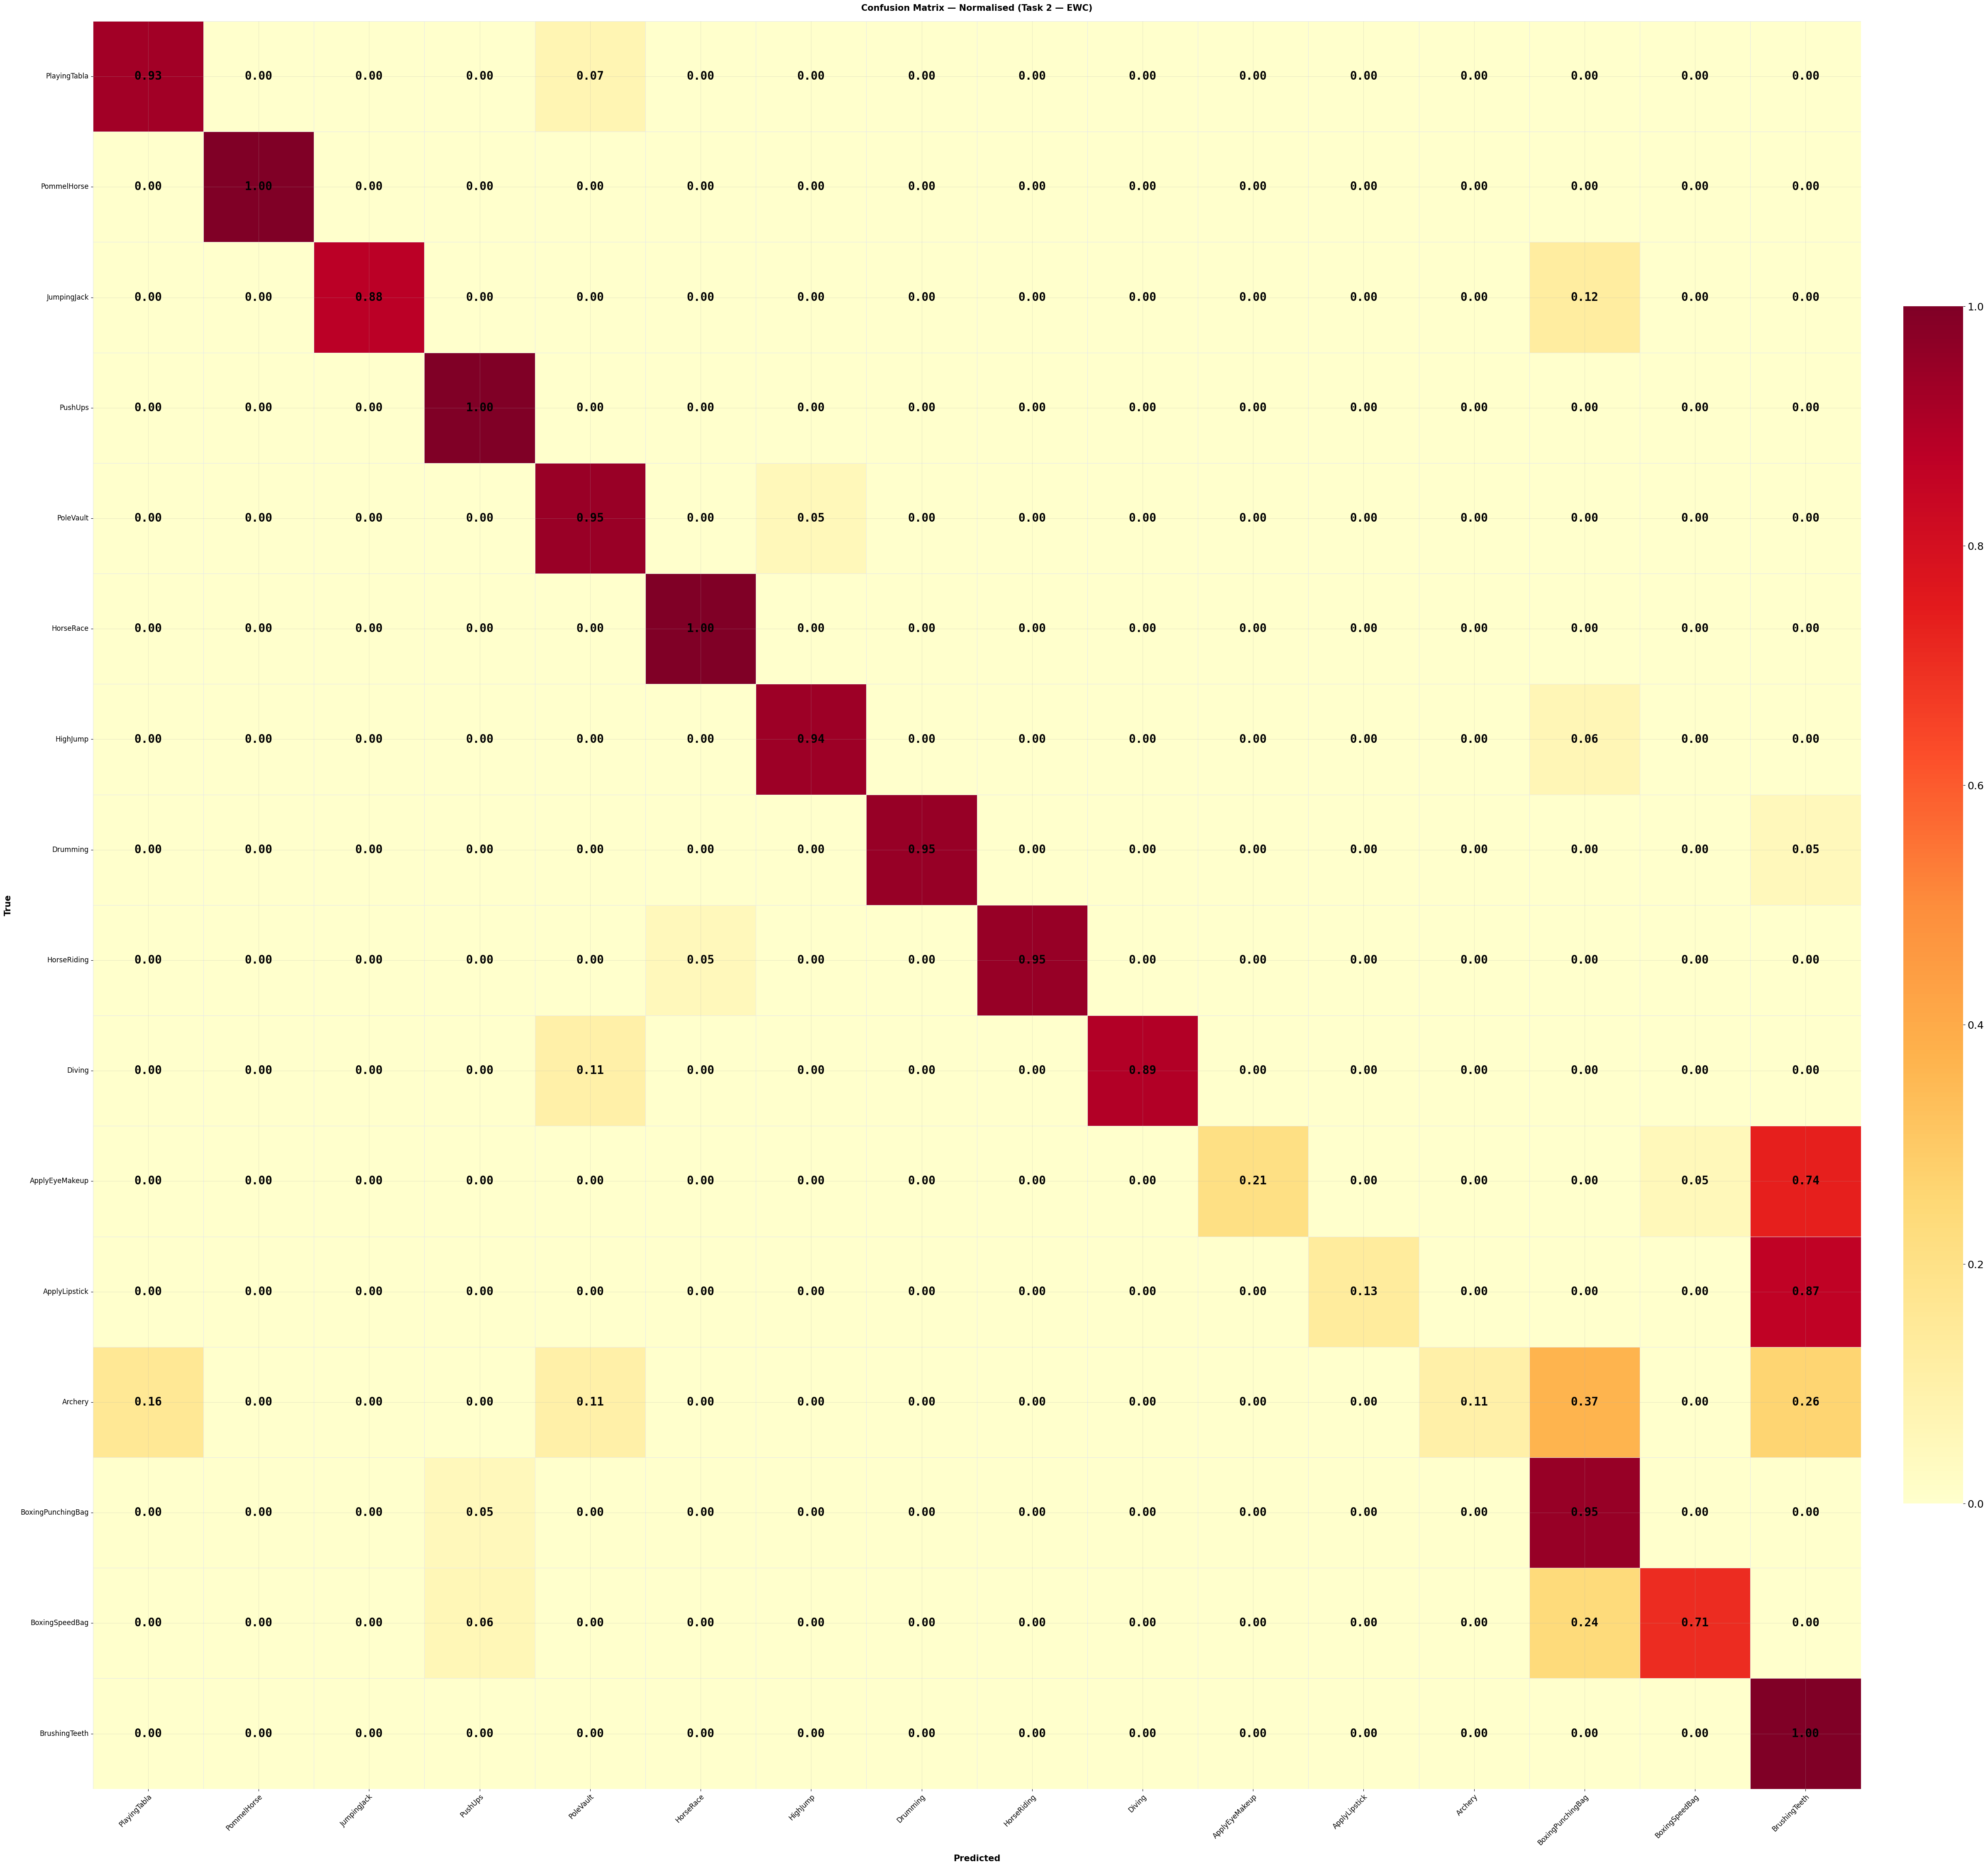

In [23]:
_, all_preds, all_labels = test_model(model_ewc, combined_t2_loader, device)
plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_T2),
    classes_list = ALL_CLASSES_T2,
    name         = "Task 2 — EWC",
)